In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

C:\Users\Admin\AppData\Local\Temp\ipykernel_52652\1312486886.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(dfs)


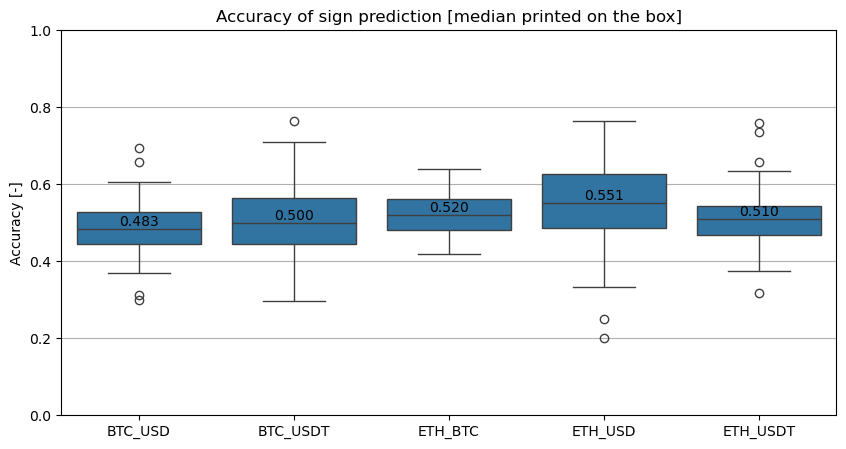

In [4]:
dfs = []

for pair in ["BTC_USD", "ETH_USD", "ETH_BTC", "BTC_USDT", "ETH_USDT"]:
    PATH = f"C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\data\\simulations_multivariate_bi\\multivariate_hawkes\\{pair}\\training_time_1500\\simulation_seconds_120"
    files = os.listdir(PATH)
    for file in files:
        df = pd.read_csv(os.path.join(PATH, file), sep="\t")
        df["file"] = file
        df["pair"] = pair
        dfs.append(df)

df = pd.concat(dfs)

df["Real Event Type MP"] = df["Real Event Type"].apply(
    lambda x: x.split("_BI_")[0]
)

df["Predicted Event Type"] = df[
    ["Predicted MP UP BI POS Time", "Predicted MP DOWN BI POS Time", "Predicted MP UP BI NEG Time", "Predicted MP DOWN BI NEG Time"]
].idxmin(axis=1)

df["Predicted Event Type"] = df["Predicted Event Type"].apply(
    lambda x: {
        "Predicted MP UP BI POS Time": "MP_UP",
         "Predicted MP DOWN BI POS Time": "MP_DOWN",
         "Predicted MP UP BI NEG Time": "MP_UP",
         "Predicted MP DOWN BI NEG Time": "MP_DOWN"
    }[x]
)

df["Correct Prediction"] = df["Predicted Event Type"] == df["Real Event Type MP"]
boxplot_df = df[["pair", "file", "Correct Prediction"]].groupby(["pair", "file"]).mean()
boxplot_df = boxplot_df.reset_index()
boxplot_df.columns = ["Pair", "file", "Accuracy"]

plt.figure(figsize=(10, 5))
sns.boxplot(data=boxplot_df, y="Accuracy", x="Pair")
plt.title("Accuracy of sign prediction [median printed on the box]")
# print in the boxplot the median accuracy
for i, method in enumerate(boxplot_df["Pair"].unique()):
    median_accuracy = boxplot_df[boxplot_df["Pair"] == method
                                    ]["Accuracy"].median()
    
    plt.text(i, median_accuracy, f"{median_accuracy:.3f}", ha='center', va='bottom')
plt.ylim(0, 1)
plt.grid(axis='y')
plt.xlabel("")
plt.ylabel("Accuracy [-]")
plt.show()

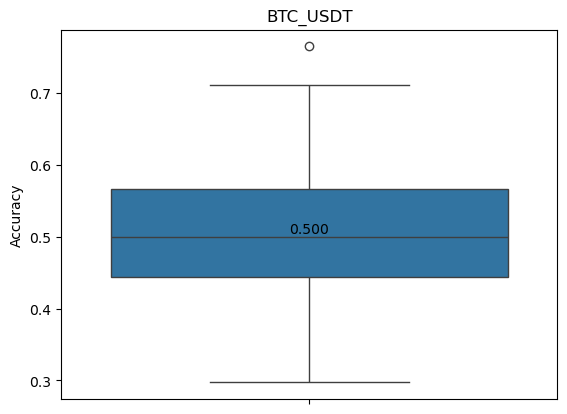

In [15]:
PATH = "C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\data\\simulations_multivariate_bi\\multivariate_hawkes\\BTC_USDT\\training_time_1500\\simulation_seconds_120"
files = os.listdir(PATH)
dfs = []
for file in files:
    df = pd.read_csv(os.path.join(PATH, file), sep="\t")
    df["file"] = file
    dfs.append(df)

df = pd.concat(dfs)

df["Real Event Type MP"] = df["Real Event Type"].apply(
    lambda x: x.split("_BI_")[0]
)

df["Predicted Event Type"] = df[
    ["Predicted MP UP BI POS Time", "Predicted MP DOWN BI POS Time", "Predicted MP UP BI NEG Time", "Predicted MP DOWN BI NEG Time"]
].idxmin(axis=1)

df["Predicted Event Type"] = df["Predicted Event Type"].apply(
    lambda x: {
        "Predicted MP UP BI POS Time": "MP_UP",
         "Predicted MP DOWN BI POS Time": "MP_DOWN",
         "Predicted MP UP BI NEG Time": "MP_UP",
         "Predicted MP DOWN BI NEG Time": "MP_DOWN"
    }[x]
)

df["Correct Prediction"] = df["Predicted Event Type"] == df["Real Event Type MP"]
boxplot_df = df[["file", "Correct Prediction"]].groupby("file").mean()
boxplot_df = boxplot_df.reset_index()
boxplot_df.columns = ["file", "Accuracy"]
sns.boxplot(data=boxplot_df, y="Accuracy")
plt.title("BTC_USDT")
# print in the boxplot the median accuracy
medians = boxplot_df["Accuracy"].median()
plt.text(0, medians, f"{medians:.3f}", ha='center', va='bottom')
plt.show()

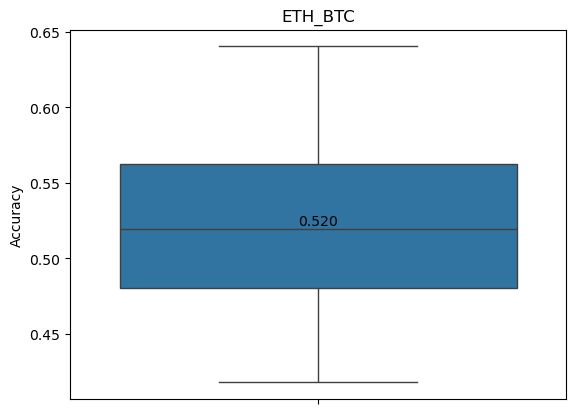

In [14]:
PATH = "C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\data\\simulations_multivariate_bi\\multivariate_hawkes\\ETH_BTC\\training_time_1500\\simulation_seconds_120"
files = os.listdir(PATH)
dfs = []
for file in files:
    df = pd.read_csv(os.path.join(PATH, file), sep="\t")
    df["file"] = file
    dfs.append(df)

df = pd.concat(dfs)

df["Real Event Type MP"] = df["Real Event Type"].apply(
    lambda x: x.split("_BI_")[0]
)

df["Predicted Event Type"] = df[
    ["Predicted MP UP BI POS Time", "Predicted MP DOWN BI POS Time", "Predicted MP UP BI NEG Time", "Predicted MP DOWN BI NEG Time"]
].idxmin(axis=1)

df["Predicted Event Type"] = df["Predicted Event Type"].apply(
    lambda x: {
        "Predicted MP UP BI POS Time": "MP_UP",
         "Predicted MP DOWN BI POS Time": "MP_DOWN",
         "Predicted MP UP BI NEG Time": "MP_UP",
         "Predicted MP DOWN BI NEG Time": "MP_DOWN"
    }[x]
)

df["Correct Prediction"] = df["Predicted Event Type"] == df["Real Event Type MP"]
boxplot_df = df[["file", "Correct Prediction"]].groupby("file").mean()
boxplot_df = boxplot_df.reset_index()
boxplot_df.columns = ["file", "Accuracy"]
sns.boxplot(data=boxplot_df, y="Accuracy")
plt.title("ETH_BTC")
# print in the boxplot the median accuracy
medians = boxplot_df["Accuracy"].median()
plt.text(0, medians, f"{medians:.3f}", ha='center', va='bottom')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_34820\3837161072.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(dfs)


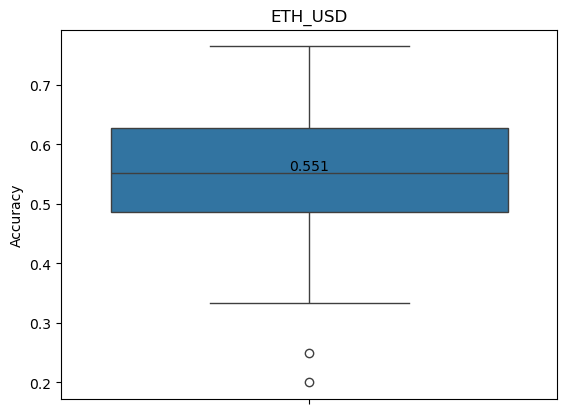

In [13]:
PATH = "C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\data\\simulations_multivariate_bi\\multivariate_hawkes\\ETH_USD\\training_time_1500\\simulation_seconds_120"
files = os.listdir(PATH)
dfs = []
for file in files:
    df = pd.read_csv(os.path.join(PATH, file), sep="\t")
    df["file"] = file
    dfs.append(df)

df = pd.concat(dfs)

df["Real Event Type MP"] = df["Real Event Type"].apply(
    lambda x: x.split("_BI_")[0]
)

df["Predicted Event Type"] = df[
    ["Predicted MP UP BI POS Time", "Predicted MP DOWN BI POS Time", "Predicted MP UP BI NEG Time", "Predicted MP DOWN BI NEG Time"]
].idxmin(axis=1)

df["Predicted Event Type"] = df["Predicted Event Type"].apply(
    lambda x: {
        "Predicted MP UP BI POS Time": "MP_UP",
         "Predicted MP DOWN BI POS Time": "MP_DOWN",
         "Predicted MP UP BI NEG Time": "MP_UP",
         "Predicted MP DOWN BI NEG Time": "MP_DOWN"
    }[x]
)

df["Correct Prediction"] = df["Predicted Event Type"] == df["Real Event Type MP"]
boxplot_df = df[["file", "Correct Prediction"]].groupby("file").mean()
boxplot_df = boxplot_df.reset_index()
boxplot_df.columns = ["file", "Accuracy"]
sns.boxplot(data=boxplot_df, y="Accuracy")
plt.title("ETH_USD")
# print in the boxplot the median accuracy
medians = boxplot_df["Accuracy"].median()
plt.text(0, medians, f"{medians:.3f}", ha='center', va='bottom')
plt.show()

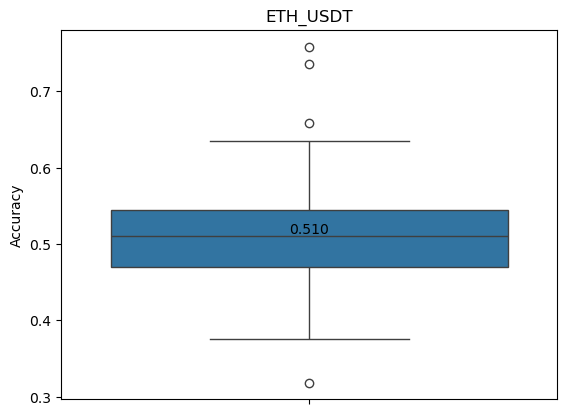

In [12]:
PATH = "C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\data\\simulations_multivariate_bi\\multivariate_hawkes\\ETH_USDT\\training_time_1500\\simulation_seconds_120"
files = os.listdir(PATH)
dfs = []
for file in files:
    df = pd.read_csv(os.path.join(PATH, file), sep="\t")
    df["file"] = file
    dfs.append(df)

df = pd.concat(dfs)

df["Real Event Type MP"] = df["Real Event Type"].apply(
    lambda x: x.split("_BI_")[0]
)

df["Predicted Event Type"] = df[
    ["Predicted MP UP BI POS Time", "Predicted MP DOWN BI POS Time", "Predicted MP UP BI NEG Time", "Predicted MP DOWN BI NEG Time"]
].idxmin(axis=1)

df["Predicted Event Type"] = df["Predicted Event Type"].apply(
    lambda x: {
        "Predicted MP UP BI POS Time": "MP_UP",
         "Predicted MP DOWN BI POS Time": "MP_DOWN",
         "Predicted MP UP BI NEG Time": "MP_UP",
         "Predicted MP DOWN BI NEG Time": "MP_DOWN"
    }[x]
)

df["Correct Prediction"] = df["Predicted Event Type"] == df["Real Event Type MP"]
boxplot_df = df[["file", "Correct Prediction"]].groupby("file").mean()
boxplot_df = boxplot_df.reset_index()
boxplot_df.columns = ["file", "Accuracy"]
sns.boxplot(data=boxplot_df, y="Accuracy")
plt.title("ETH_USDT")
# print in the boxplot the median accuracy
medians = boxplot_df["Accuracy"].median()
plt.text(0, medians, f"{medians:.3f}", ha='center', va='bottom')
plt.show()

In [4]:
def compute_average(filename):
    try:
        with open(filename, 'r') as file:
            numbers = [float(line.strip()) for line in file if line.strip()]
        
        if not numbers:
            print("No valid numbers found in the file.")
            return None
        
        average = sum(numbers) / len(numbers)
        print(f"Average: {average}")
        return average
    except FileNotFoundError:
        print("Error: File not found.")
    except ValueError:
        print("Error: File contains non-numeric data.")

# Example usage
filename = "C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\data\\simulations\\multivariate_hawkes\\ETH_USDT\\training_time_1500\\simulation_seconds_120\\times_simulation.txt"  # Change to your file name
compute_average(filename)

Average: 0.001400863181811373


0.001400863181811373